In [34]:
import numpy as np
import pandas as pd

In [35]:
df = pd.read_csv("spam.csv",encoding = "cp1252")

In [36]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [37]:
df.shape

(5572, 5)

In [38]:
# Data Cleaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [39]:
# drop the columns
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [40]:
#rename the columns
df.rename(columns={"v1":"target","v2":"text"},inplace=True)

In [41]:
df.sample(5)

,target,text
871,ham,Its going good...no problem..but still need li...
4180,ham,"Ok da, i already planned. I wil pick you."
1491,spam,Your account has been credited with 500 FREE T...
1766,spam,SMS AUCTION You have won a Nokia 7250i. This i...
3466,spam,URGENT! We are trying to contact U. Todays dra...


In [42]:
# for converting ham and spam into 0 and 1
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["target"]=encoder.fit_transform(df["target"])

In [43]:
df.sample(5)

,target,text
4751,0,Well boy am I glad G wasted all night at apple...
3038,0,"Wishing you and your family Merry \X\"" mas and..."
171,0,"Hmmm.. Thk sure got time to hop ard... Ya, can..."
5022,0,Anyway holla at me whenever you're around beca...
3714,0,"I am late,so call you tomorrow morning.take ca..."


In [44]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(403)

In [46]:
df = df.drop_duplicates(keep="first")

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
# 2.EDA

df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [49]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

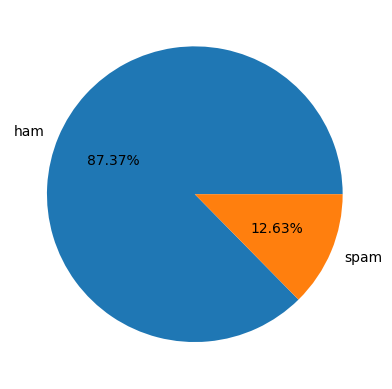

In [50]:
import matplotlib.pyplot as plt
plt.pie(df["target"].value_counts(),labels=["ham","spam"],autopct="%0.2f%%")
plt.show()

In [51]:
! pip install nltk


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import nltk

In [53]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Komal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [54]:
df["num_char"] = df["text"].apply(len)

C:\Users\Komal\AppData\Local\Temp\ipykernel_132\2850368079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_char"] = df["text"].apply(len)


In [55]:
df

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [56]:
df["num_words"] = df["text"].apply(lambda x: len(nltk.word_tokenize(x)))

C:\Users\Komal\AppData\Local\Temp\ipykernel_132\1075540409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_words"] = df["text"].apply(lambda x: len(nltk.word_tokenize(x)))


In [57]:
df

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [58]:
df["num_sent"] = df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))

C:\Users\Komal\AppData\Local\Temp\ipykernel_132\3846090885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_sent"] = df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))


In [59]:
df

,target,text,num_char,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [60]:
df[["num_char","num_words","num_sent"]].describe()

,num_char,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [61]:
# ham
df[df["target"]==0][["num_char","num_words","num_sent"]].describe()

,num_char,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [62]:
# spam
df[df["target"]==1][["num_char","num_words","num_sent"]].describe()

,num_char,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


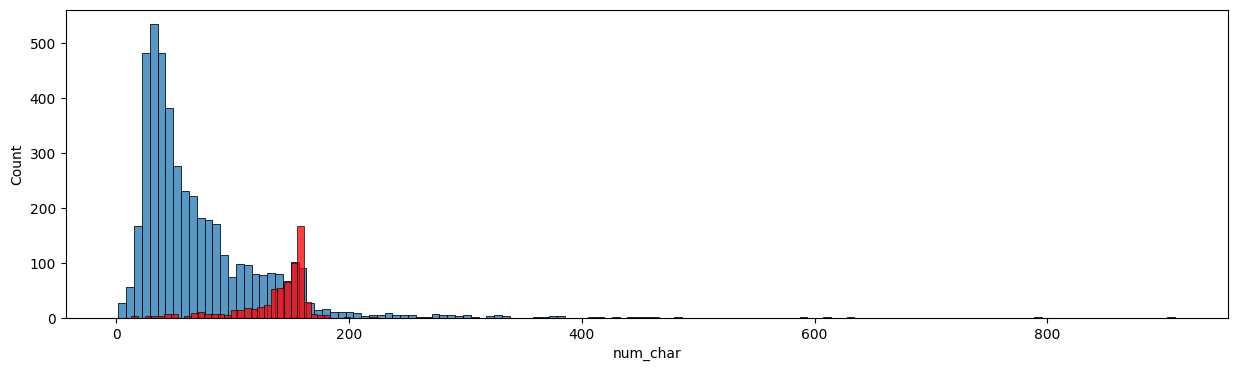

In [63]:
! pip install seaborn
import seaborn as sns
plt.figure(figsize=(15,4))
sns.histplot(data=df[df["target"]==0], x = "num_char")
sns.histplot(data=df[df["target"]==1],x="num_char",color="red")
plt.show()

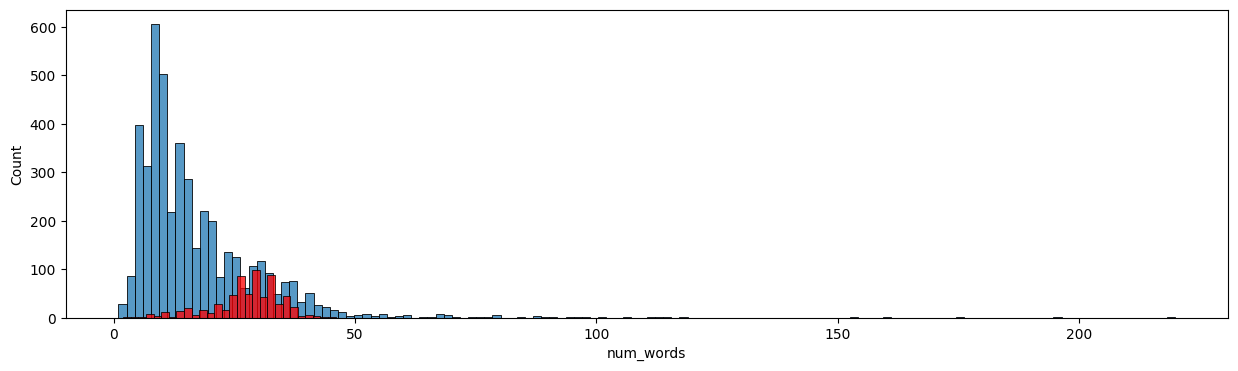

In [64]:
plt.figure(figsize=(15,4))
sns.histplot(data=df[df["target"]==0], x = "num_words")
sns.histplot(data=df[df["target"]==1],x="num_words",color="red")
plt.show()

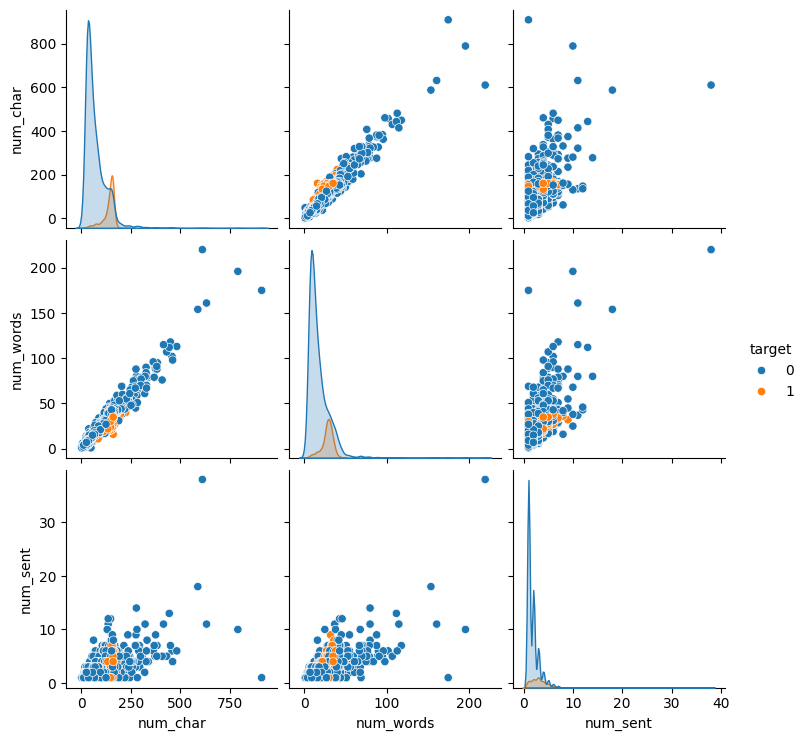

In [65]:
sns.pairplot(df,hue="target")

<Axes: >

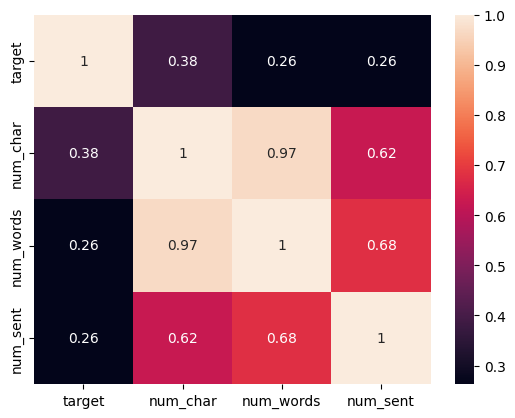

In [66]:
sns.heatmap(df.corr(numeric_only= True),annot=True)

In [67]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stopwords.words("english")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Komal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [68]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [69]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem("dancing")

'danc'

In [70]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [71]:
transform_text("hii how are you komal??")

'hii komal'

In [72]:
df["text_transform"] = df["text"].apply(transform_text)

C:\Users\Komal\AppData\Local\Temp\ipykernel_132\2162346640.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["text_transform"] = df["text"].apply(transform_text)


In [73]:
df

,target,text,num_char,num_words,num_sent,text_transform
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/301.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/301.2 kB ? eta -:--:--
   ----- --------------------------------- 41.0/301.2 kB 326.8 kB/s eta 0:00:01
   -------------- ----------------------- 112.6/301.2 kB 656.4 kB/s eta 0:00:01
   ------------------------ ------------- 194.6/301.2 kB 908.0 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 919.0 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 919.0 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 919.0 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 919.0 kB/s eta 0:00:01
   -------------------------------------- 301.2/301.2 kB 689.4 kB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


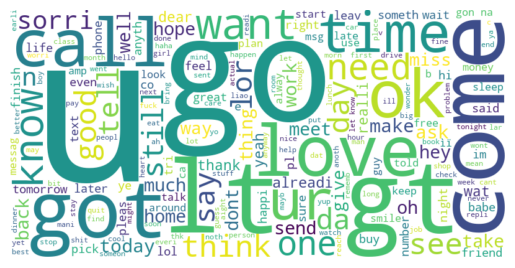

In [75]:
! pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt


ham_messages = df[df["target"] == 0]["text_transform"].str.cat(sep=" ")


# Generate and display the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_messages)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


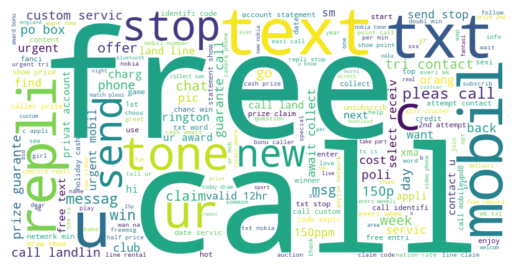

In [76]:
ham_messages = df[df["target"] == 1]["text_transform"].str.cat(sep=" ")


# Generate and display the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_messages)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [77]:
spam_corpus = []
for msg in df[df["target"] == 1]["text_transform"].tolist():
       for word in msg.split():
           spam_corpus.append(word)

In [48]:
spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [49]:
len(spam_corpus)

9939

In [78]:
! pip install collection

  Using cached collection-0.1.6-py3-none-any.whl



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [79]:
ham_corpus = []
for msg in df[df["target"] == 0]["text_transform"].tolist():
       for word in msg.split():
           ham_corpus.append(word)

In [54]:
len(ham_corpus)

35404

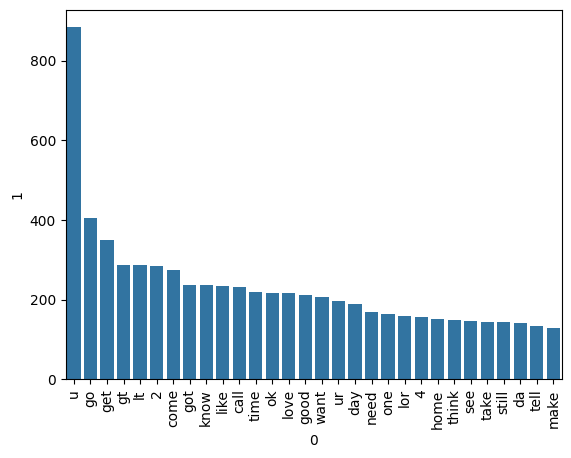

In [80]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [81]:
spam_corpus = []
for msg in df[df["target"] == 1]["text_transform"].tolist():
       for word in msg.split():
           spam_corpus.append(word)

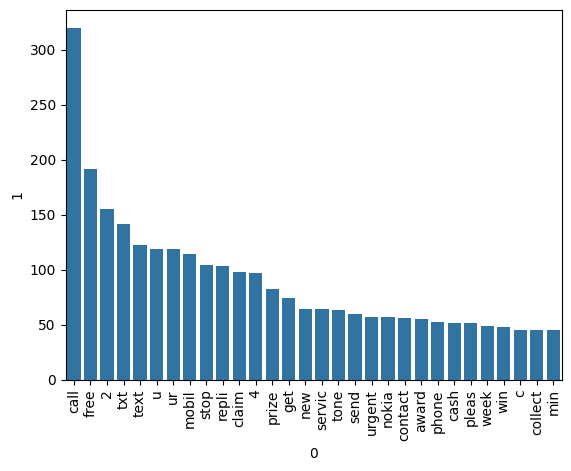

In [58]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [59]:
df.head()

,target,text,num_char,num_words,num_sent,text_transform
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
# model buiding

In [82]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
tfidf = TfidfVectorizer()
cv = CountVectorizer()

In [83]:
x= tfidf.fit_transform(df["text_transform"]).toarray()

In [84]:
y=df["target"].values

In [85]:
x.shape

(5169, 6708)

In [86]:
y.shape

(5169,)

In [87]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.23, random_state=2)
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [88]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


In [80]:
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(precision_score(y_test, y_pred))

0.8654331370899916
[[903 133]
 [ 27 126]]
0.4864864864864865


In [89]:
mnb.fit(X_train, y_train)
y_pred1 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.9596299411269975
[[1036    0]
 [  48  105]]
1.0


In [82]:
bnb.fit(X_train, y_train)
y_pred2 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9671993271656855
[[1032    4]
 [  35  118]]
0.9672131147540983


In [90]:
""" overfitting is occure when max_depth is high and underfitting is occure when max_depth is very less"""

from sklearn import tree
clf = tree.DecisionTreeClassifier(criterion ="entropy",max_depth = None)
clf = clf.fit(X_train,y_train)
y_pred4 = clf.predict(X_test)
print(accuracy_score(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))
print(precision_score(y_test,y_pred4))

0.9428090832632464
[[1009   27]
 [  41  112]]
0.8057553956834532


In [85]:
! pip install xgboost

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [87]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [88]:
"""clf = clf.fit(X_train,y_train)
svc = svc.fit(X_train,y_train)
knc = knc.fit(X_train,y_train)
mnb = mnb.fit(X_train,y_train)
dtc = dtc.fit(X_train,y_train)
lrc = lrc.fit(X_train,y_train)
rfc = rfc.fit(X_train,y_train)
abc = abc.fit(X_train,y_train)
bc = bc.fit(X_train,y_train)
etc = etc.fit(X_train,y_train)
gbdt = gbdt.fit(X_train,y_train)
xgb = xgb.fit(X_train,y_train)"""

'clf = clf.fit(X_train,y_train)\nsvc = svc.fit(X_train,y_train)\nknc = knc.fit(X_train,y_train)\nmnb = mnb.fit(X_train,y_train)\ndtc = dtc.fit(X_train,y_train)\nlrc = lrc.fit(X_train,y_train)\nrfc = rfc.fit(X_train,y_train)\nabc = abc.fit(X_train,y_train)\nbc = bc.fit(X_train,y_train)\netc = etc.fit(X_train,y_train)\ngbdt = gbdt.fit(X_train,y_train)\nxgb = xgb.fit(X_train,y_train)'

In [89]:
"""y_pred5 = knc.predict(X_test)
print(accuracy_score(y_test,y_pred5))
print(confusion_matrix(y_test,y_pred5))
print(precision_score(y_test,y_pred5))"""

'y_pred5 = knc.predict(X_test)\nprint(accuracy_score(y_test,y_pred5))\nprint(confusion_matrix(y_test,y_pred5))\nprint(precision_score(y_test,y_pred5))'

In [90]:
"""y_pred6 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred6))
print(confusion_matrix(y_test,y_pred6))
print(precision_score(y_test,y_pred6))"""

'y_pred6 = mnb.predict(X_test)\nprint(accuracy_score(y_test,y_pred6))\nprint(confusion_matrix(y_test,y_pred6))\nprint(precision_score(y_test,y_pred6))'

In [91]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [92]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [93]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9747687132043734, 0.9767441860465116)

In [94]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9747687132043734
Precision -  0.9767441860465116
For  KN
Accuracy -  0.9015979814970564
Precision -  1.0
For  NB
Accuracy -  0.9596299411269975
Precision -  1.0
For  DT
Accuracy -  0.936080740117746
Precision -  0.8347826086956521
For  LR
Accuracy -  0.9529015979814971
Precision -  0.9369369369369369
For  RF
Accuracy -  0.9722455845248108
Precision -  0.9918032786885246
For  AdaBoost
Accuracy -  0.926829268292683
Precision -  0.8367346938775511
For  BgC
Accuracy -  0.9621530698065601
Precision -  0.875
For  ETC
Accuracy -  0.9781328847771237
Precision -  0.9847328244274809
For  GBDT
Accuracy -  0.9512195121951219
Precision -  0.9279279279279279
For  xgb
Accuracy -  0.9730866274179983
Precision -  0.9481481481481482


In [95]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [96]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [97]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [98]:
VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [99]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9789739276703112
Precision 0.9923076923076923


In [102]:
import pickle
pickle.dump(tfidf,open("vectorizer.pkl","wb"))
pickle.dump(mnb,open("model.pkl","wb"))